# Lab 1

## Estimating worst-case/average-case complexity of algorithms via linear and binary search.

### 1. Linear Search

In [1]:
import math
import random

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

In [2]:
n = 0 # no. of iterations

In [3]:
def linearSearch(arr, q):
    global n
    for i in range(1, len(arr)):
        n = n + 1
        if (arr[i] == q):
            return i

In [4]:
def testLinearSearch(num, maxRandLimit):
    # Build Data
    arr = []
    global n
    n = 0
    for i in range(num):
        arr.append(random.randint(0,maxRandLimit))
    q=random.randint(0,maxRandLimit)
    # Run the algorithm
    linearSearch(arr,q)
    return n

def data_builder(n):
    arr = []
    for i in range(1, n):
        # print(10**i)
        for j in range(1, 10):
            arr.append((10**i)*j)
    return arr

def run_n_times(iterations, sample_size):
    # initialise datastores
    test_sizes = data_builder(sample_size)
    results = [0 for i in range(len(test_sizes))]
    # run the tests for iterations
    for i in range(iterations):
        for j in range(len(test_sizes)):
            results[j] += testLinearSearch(test_sizes[j], test_sizes[j])
    # calculate avg comparisons
    for i in range(len(results)):
        results[i] = results[i]//iterations
    return (test_sizes, results)

In [5]:
ITER_RUNS = 25
RUN_SIZE = 4
test_sizes, results = run_n_times(ITER_RUNS, RUN_SIZE)
print(results)

[6, 12, 18, 25, 26, 40, 47, 45, 54, 69, 122, 150, 267, 350, 398, 521, 524, 635, 583, 1427, 2112, 2339, 3058, 3482, 4204, 3874, 5265]


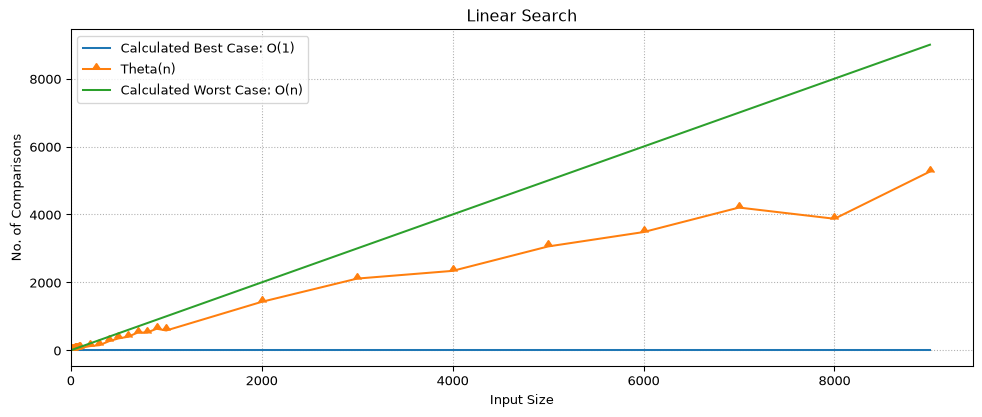

In [6]:
figure(figsize=(12, 4.5), dpi=97)

x = test_sizes[:]
y1 = [1 for i in test_sizes[:]] # best case
y2 = results[:] # avg case
y3 = [i for i in test_sizes[:]] # worst case

plt.plot(x, y1, label="Calculated Best Case: O(1)")
plt.plot(x, y2, label="Theta(n)", marker=10)
plt.plot(x, y3, label="Calculated Worst Case: O(n)")

plt.xlim(left=0)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("No. of Comparisons")
plt.title("Linear Search")
plt.grid(visible=True, linestyle=':')
plt.show()

### 2. Binary Search

In [7]:
n=0
def binarySearch(arr, q, low, high):
    global n
    if (low > high) or ((low == high) and (q != low)) or (high >= len(arr)):
        return None
    mid = int((high - low)//2) + low
    if arr[mid] == q:
        n += 1
        return mid
    if q < arr[mid]:
        n += 1
        return binarySearch(arr, q, low, mid-1)
    if q > arr[mid]:
        n += 1
        return binarySearch(arr, q, mid+1, high)
    return None

In [8]:
def testBinarySearch(num, maxRandLimit):
    # Build Data
    arr = []
    global n
    n = 0
    for i in range(num):
        arr.append(random.randint(0,maxRandLimit))
    q=random.randint(0,maxRandLimit)
    # Run the algorithm
    binarySearch(arr,q,0,num-1)
    return n

def run_n_times_binary(iterations, sample_size):
    # initialise datastores
    test_sizes = data_builder(sample_size)
    results = [0 for i in range(len(test_sizes))]
    # run the tests for iterations
    for i in range(iterations):
        for j in range(len(test_sizes)):
            results[j] += testBinarySearch(test_sizes[j], test_sizes[j])
    # calculate avg comparisons
    for i in range(len(results)):
        results[i] = results[i]//iterations
    return (test_sizes, results)

In [9]:
ITER_RUNS = 25
RUN_SIZE = 4
test_sizes, results_b = run_n_times_binary(ITER_RUNS, RUN_SIZE)
print(results_b)

[2, 3, 3, 4, 4, 4, 5, 5, 5, 5, 6, 7, 8, 8, 8, 8, 8, 8, 9, 10, 10, 11, 11, 11, 12, 12, 12]


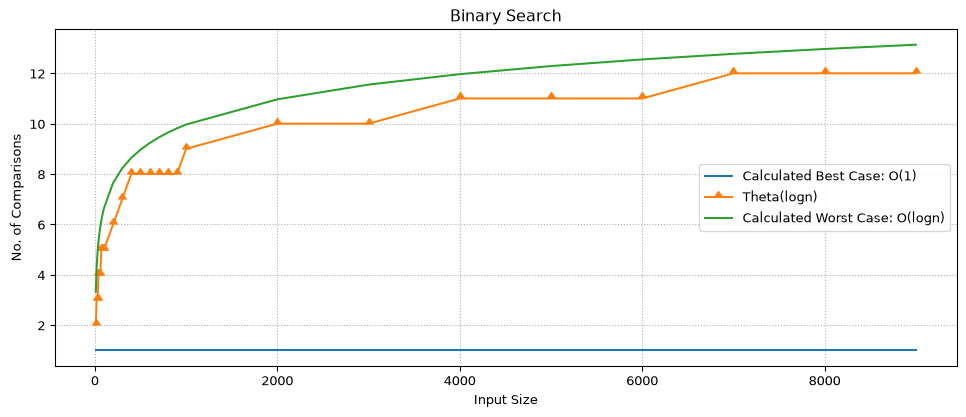

In [10]:
figure(figsize=(12, 4.5), dpi=97)

x = test_sizes[:]
y1 = [1 for i in test_sizes[:]] # best case
y2 = results_b[:] # avg case
y3 = [math.log2(i) for i in test_sizes[:]] # worst case

plt.plot(x, y1, label="Calculated Best Case: O(1)")
plt.plot(x, y2, label="Theta(logn)", marker=10)
plt.plot(x, y3, label="Calculated Worst Case: O(logn)")

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("No. of Comparisons")
plt.title("Binary Search")
plt.grid(visible=True, linestyle=':')
plt.show()

### 3. Comparison b/w Linear and Binary Search Algorithms

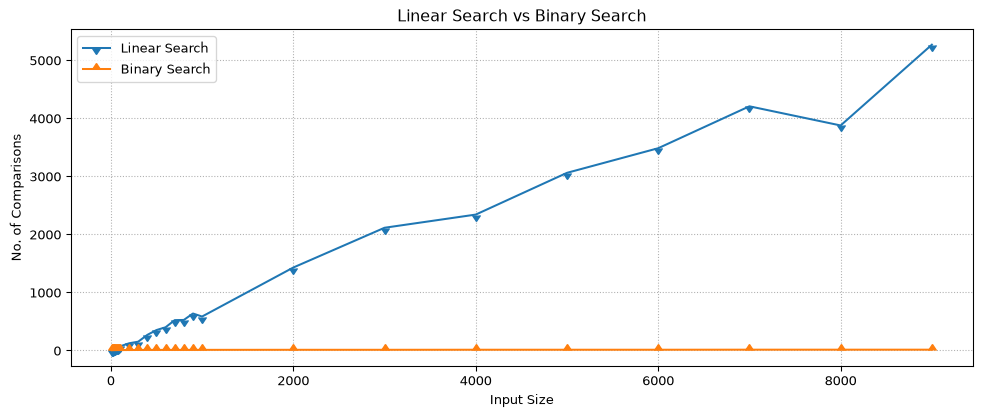

In [11]:
figure(figsize=(12, 4.5), dpi=97)

x = test_sizes[:]
y1 = results[:] # Linear Search
y2 = results_b[:] # Binary Search

plt.plot(x, y1, label="Linear Search", marker=11)
plt.plot(x, y2, label="Binary Search", marker=10)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("No. of Comparisons")
plt.title("Linear Search vs Binary Search")
plt.grid(visible=True, linestyle=':')
plt.show()